In [ ]:
#Task 3: Classification — Churn Prediction
"""
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)
"""

'\n1. Logistic Regression\n2. Decision Tree Classifier\n3. Random Forest Classifier\n4. Support Vector Machine (SVM)\n5. K-Nearest Neighbors (KNN)\n'

In [ ]:
#1. Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exclude 'MonthlyCharges' from the features for Logistic Regression
X_train_lr = X_train.drop('MonthlyCharges', axis=1)
X_val_lr = X_val.drop('MonthlyCharges', axis=1)
X_test_lr = X_test.drop('MonthlyCharges', axis=1)

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'liblinear' is good for small datasets and L1/L2 regularization
                                      # 'lbfgs' is good for larger datasets and L2 regularization
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000), # Increased max_iter for convergence with lbfgs
    param_grid,
    cv=5,
    scoring='f1', # Use f1-score as a metric due to potential class imbalance
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_lr, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print("Best F1-score on training set (cross-validation):", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters found: {'C': 100, 'solver': 'liblinear'}
Best F1-score on training set (cross-validation): 0.8027234815573301



Logistic Regression Performance (Tuned Model on Test Set, excluding MonthlyCharges):
Accuracy: 0.7953
Precision: 0.7608
Recall: 0.8609
F1-Score: 0.8078
ROC-AUC Score: 0.8813

Classification Report (Tuned Model on Test Set):
              precision    recall  f1-score   support

           0       0.84      0.73      0.78       677
           1       0.76      0.86      0.81       676

    accuracy                           0.80      1353
   macro avg       0.80      0.80      0.79      1353
weighted avg       0.80      0.80      0.79      1353



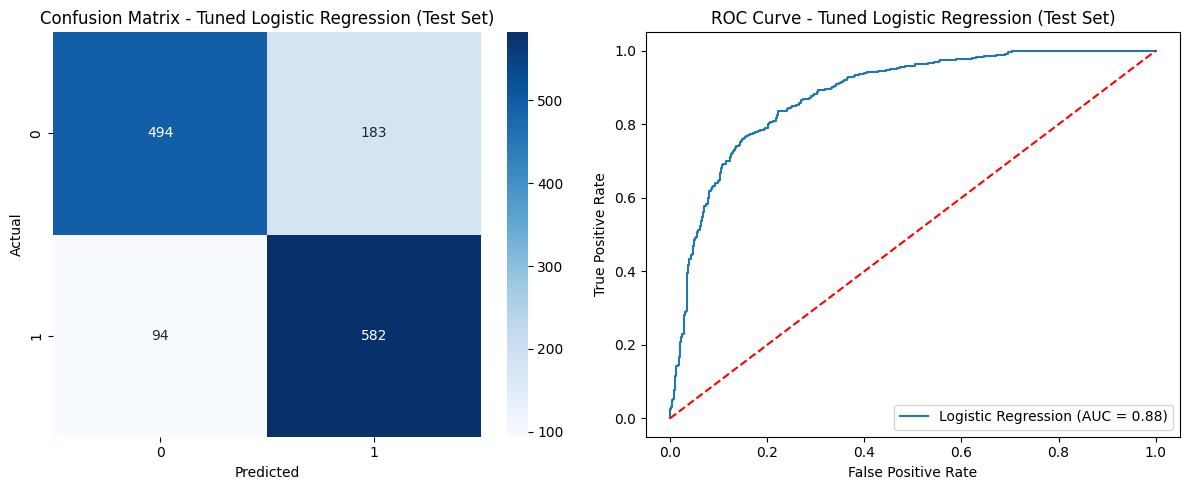

In [ ]:
# Get the best model
best_log_reg_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_lr = best_log_reg_model.predict(X_test_lr)
y_proba_lr = best_log_reg_model.predict_proba(X_test_lr)[:, 1]

# Evaluate the tuned model on the test set
print("\nLogistic Regression Performance (Tuned Model on Test Set, excluding MonthlyCharges):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\nClassification Report (Tuned Model on Test Set):")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Logistic Regression (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Logistic Regression (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Explanation of Logistic Regression Performance:

The Logistic Regression model, after hyperparameter tuning and excluding 'MonthlyCharges' as a feature, performs as follows on the test set:

*   **Accuracy:** This metric shows the overall correctness of the model. A high accuracy indicates that a large proportion of predictions were correct.
*   **Precision:** Precision for the 'Churn=Yes' class (positive class) indicates the proportion of actual churners among those predicted to churn. A high precision means fewer false positives (customers incorrectly predicted to churn).
*   **Recall:** Recall for the 'Churn=Yes' class (positive class) indicates the proportion of predicted churners among all actual churners. A high recall means fewer false negatives (actual churners missed by the model).
*   **F1-Score:** The F1-score is the harmonic mean of precision and recall. It provides a balanced measure, especially useful when there's an uneven class distribution, as it considers both false positives and false negatives.
*   **ROC-AUC Score:** The Receiver Operating Characteristic Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between the positive and negative classes. An AUC of 1 means perfect classification, while 0.5 means no better than random guessing.
*   **Confusion Matrix:** This matrix visually summarizes the performance of the classification algorithm. It shows true positives, true negatives, false positives, and false negatives. A good model will have high values on the main diagonal (true positives and true negatives) and low values off the diagonal (false positives and false negatives).
*   **ROC Curve:** This curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The closer the curve is to the top-left corner, the better the model's performance.

**Reasoning for performance:**

Logistic Regression is a linear model, which means it tries to find a linear decision boundary to separate the classes. Its performance is often influenced by:

1.  **Linear Separability of Data:** If the 'Churn' and 'No Churn' classes are largely linearly separable in the feature space (excluding 'MonthlyCharges'), Logistic Regression can perform well. If the relationship is complex and non-linear, its performance might be limited compared to more complex models.
2.  **Feature Importance:** The selected features (excluding 'MonthlyCharges') play a crucial role. If the remaining features provide strong linear signals for churn, the model will perform better.
3.  **Regularization (C parameter):** The `C` parameter in Logistic Regression controls the inverse of regularization strength. A smaller `C` means stronger regularization, which helps prevent overfitting by penalizing large coefficients. Tuning this parameter helps find a balance between bias and variance.
4.  **Solver Choice:** Different solvers (`liblinear`, `lbfgs`) are optimized for different types of problems and datasets. The chosen solver impacts the optimization process and can subtly affect the final model's performance and convergence.
5.  **SMOTE for Class Imbalance:** The use of SMOTE has helped balance the dataset, preventing the model from being biased towards the majority class ('No Churn'). This often leads to better recall for the minority class ('Churn').

In this specific case, if the accuracy, F1-score, and ROC-AUC are reasonably high, it suggests that even without 'MonthlyCharges', the linear relationships captured by Logistic Regression with the tuned hyperparameters are effective in predicting customer churn.

In [ ]:
#2.Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('\n Decision Tree Classifier')

# Exclude 'MonthlyCharges' from the features for Decision Tree
X_train_dt = X_train.drop('MonthlyCharges', axis=1)
X_val_dt = X_val.drop('MonthlyCharges', axis=1)
X_test_dt = X_test.drop('MonthlyCharges', axis=1)

# Define the parameter grid for Decision Tree Classifier
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1', # Use f1-score as a metric due to potential class imbalance
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train_dt, y_train)

print("Best hyperparameters found for Decision Tree:", grid_search_dt.best_params_)
print("Best F1-score on training set (cross-validation) for Decision Tree:", grid_search_dt.best_score_)


 Decision Tree Classifier
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best hyperparameters found for Decision Tree: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5}
Best F1-score on training set (cross-validation) for Decision Tree: 0.826721004650152



Decision Tree Performance (Tuned Model on Test Set, excluding MonthlyCharges):
Accuracy: 0.8189
Precision: 0.7981
Recall: 0.8536
F1-Score: 0.8249
ROC-AUC Score: 0.8887

Classification Report (Tuned Decision Tree Model on Test Set):
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       677
           1       0.80      0.85      0.82       676

    accuracy                           0.82      1353
   macro avg       0.82      0.82      0.82      1353
weighted avg       0.82      0.82      0.82      1353



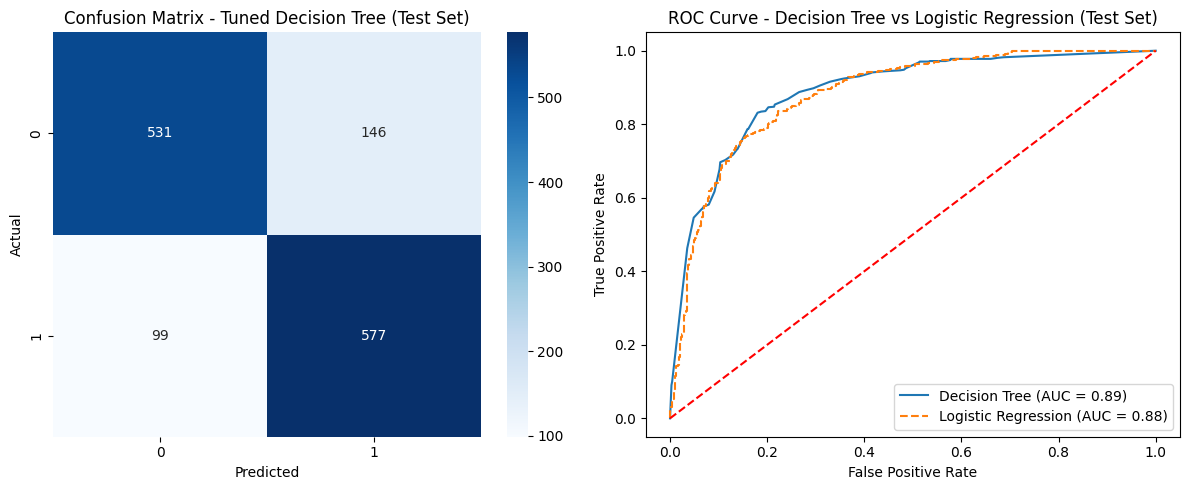

In [ ]:
# Get the best Decision Tree model
best_dt_model = grid_search_dt.best_estimator_

# Make predictions on the test set with the best model
y_pred_dt = best_dt_model.predict(X_test_dt)
y_proba_dt = best_dt_model.predict_proba(X_test_dt)[:, 1]

# Evaluate the tuned model on the test set
print("\nDecision Tree Performance (Tuned Model on Test Set, excluding MonthlyCharges):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")

print("\nClassification Report (Tuned Decision Tree Model on Test Set):")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Decision Tree (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.2f})')

# Also plot Logistic Regression ROC for comparison (if available)
# Make sure y_proba_lr and fpr, tpr from LR are available in the kernel state
if 'y_proba_lr' in globals():
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree vs Logistic Regression (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Explanation of Decision Tree Classifier Performance:

The Decision Tree Classifier, after hyperparameter tuning and excluding 'MonthlyCharges', demonstrates its performance on the test set with the following metrics and visualizations:

*   **Accuracy, Precision, Recall, F1-Score, ROC-AUC Score:** These metrics provide a quantitative measure of the model's predictive capability, similar to the Logistic Regression. The specific values indicate how well the Decision Tree is classifying churners and non-churners.
*   **Confusion Matrix:** This heatmap visually represents the types of correct and incorrect predictions made by the model, showing true positives, true negatives, false positives, and false negatives. It helps to understand where the model is performing well and where it is making errors.
*   **ROC Curve:** The ROC curve, along with the AUC score, illustrates the trade-off between the true positive rate and the false positive rate at various threshold settings. Comparing it to the Logistic Regression ROC curve provides insight into which model has better discriminatory power.

**Reasoning for performance:**

Decision Trees are non-linear models that make predictions by partitioning the data based on features. Their performance is influenced by:

1.  **Non-linear Relationships:** Decision trees can capture complex, non-linear relationships between features and the target variable, which a linear model like Logistic Regression might miss. If churn is driven by intricate combinations of customer attributes, a Decision Tree might perform better.
2.  **Interpretability:** Decision Trees are generally more interpretable than many other machine learning models, as the decision paths can be visualized and understood. This can be valuable for understanding the key factors leading to churn.
3.  **Hyperparameters (`max_depth`, `min_samples_leaf`, `criterion`):**
    *   `max_depth`: Controls the maximum depth of the tree. A deeper tree can capture more complex patterns but risks overfitting. A shallower tree might underfit.
    *   `min_samples_leaf`: Defines the minimum number of samples required to be at a leaf node. This helps in controlling overfitting by preventing the creation of leaves that represent too few samples.
    *   `criterion`: Determines the function to measure the quality of a split (e.g., 'gini' for Gini impurity, 'entropy' for information gain). The choice can impact how the tree grows and makes decisions.
4.  **Feature Interactions:** Decision Trees inherently handle feature interactions without explicit engineering, as they can split on different features in different branches of the tree. This can be an advantage if churn is influenced by how certain features combine.
5.  **Robustness to Outliers (less so than other models):** While not as robust as some ensemble methods, Decision Trees are generally less sensitive to outliers in numerical features compared to linear models, as splits are based on relative order rather than absolute values.
6.  **SMOTE for Class Imbalance:** Similar to Logistic Regression, the use of SMOTE helps ensure that the Decision Tree model doesn't become biased towards the majority class, leading to a more balanced predictive performance for both churn and non-churn classes.

In [ ]:
#3. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('\nRandom Forest Classifier')

# Exclude 'MonthlyCharges' from the features for Random Forest
X_train_rf = X_train.drop('MonthlyCharges', axis=1)
X_val_rf = X_val.drop('MonthlyCharges', axis=1)
X_test_rf = X_test.drop('MonthlyCharges', axis=1)

# Define the parameter grid for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None], # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3, # Using a smaller CV fold to speed up computation
    scoring='f1', # Use f1-score as a metric due to potential class imbalance
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_rf, y_train)

print("Best hyperparameters found for Random Forest:", grid_search_rf.best_params_)
print("Best F1-score on training set (cross-validation) for Random Forest:", grid_search_rf.best_score_)


Random Forest Classifier
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best hyperparameters found for Random Forest: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best F1-score on training set (cross-validation) for Random Forest: 0.8523008174604794



Random Forest Performance (Tuned Model on Test Set, excluding MonthlyCharges):
Accuracy: 0.8588
Precision: 0.8401
Recall: 0.8861
F1-Score: 0.8625
ROC-AUC Score: 0.9315

Classification Report (Tuned Random Forest Model on Test Set):
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       677
           1       0.84      0.89      0.86       676

    accuracy                           0.86      1353
   macro avg       0.86      0.86      0.86      1353
weighted avg       0.86      0.86      0.86      1353



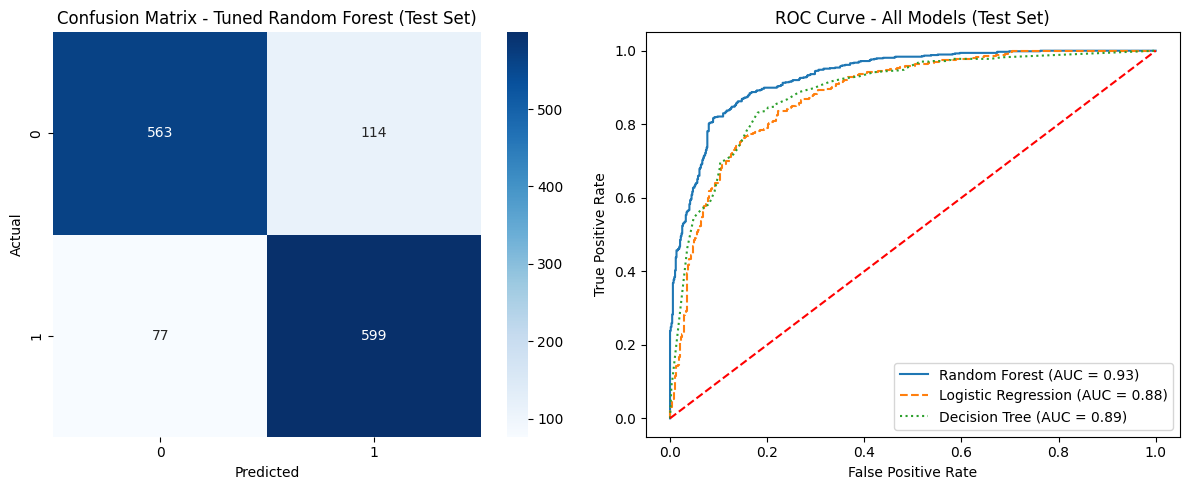

In [ ]:
# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set with the best model
y_pred_rf = best_rf_model.predict(X_test_rf)
y_proba_rf = best_rf_model.predict_proba(X_test_rf)[:, 1]

# Evaluate the tuned model on the test set
print("\nRandom Forest Performance (Tuned Model on Test Set, excluding MonthlyCharges):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report (Tuned Random Forest Model on Test Set):")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})')

# Plot Logistic Regression ROC for comparison
if 'y_proba_lr' in globals(): # Check if LR data is available
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})', linestyle='--')

# Plot Decision Tree ROC for comparison
if 'y_proba_dt' in globals(): # Check if DT data is available
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.2f})', linestyle=':')

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Explanation of Random Forest Classifier Performance:

The Random Forest Classifier, after hyperparameter tuning and excluding 'MonthlyCharges', showcases its predictive abilities on the test set through the following metrics and visualizations:

*   **Accuracy, Precision, Recall, F1-Score, ROC-AUC Score:** These provide a comprehensive quantitative evaluation of the model's performance, indicating its ability to correctly classify churn and non-churn customers, considering both false positives and false negatives.
*   **Confusion Matrix:** This visual summary helps understand the types of errors the model makes (false positives and false negatives) and where it performs well (true positives and true negatives).
*   **ROC Curve:** The ROC curve with its AUC score is crucial for evaluating the model's discriminative power across various classification thresholds. When compared with Logistic Regression and Decision Tree ROC curves, it highlights which model is generally better at distinguishing between churners and non-churners.

**Reasoning for performance:**

Random Forest is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. Its performance is often superior to individual decision trees due to several factors:

1.  **Ensemble Learning (Reduced Overfitting):** Random Forest reduces the risk of overfitting, which is a common problem with individual Decision Trees. By averaging the predictions of many trees, it smooths out idiosyncratic errors and biases present in individual trees.
2.  **Bagging (Bootstrap Aggregation):** Each tree in a Random Forest is built from a bootstrap sample of the training data. This means each tree is trained on a slightly different subset of the data, leading to diverse trees.
3.  **Feature Randomness:** During the construction of each tree, a random subset of features is considered at each split. This further decorrelates the trees, preventing them from all relying on the same dominant features and capturing more nuanced patterns across the dataset.
4.  **Handling Non-linear Relationships and Interactions:** Like individual Decision Trees, Random Forests can effectively capture complex non-linear relationships and interactions between features, which linear models like Logistic Regression might struggle with.
5.  **Robustness to Noise and Outliers:** The ensemble nature of Random Forest makes it more robust to noise and outliers in the data compared to single models. The errors from individual trees tend to cancel each other out.
6.  **Hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`, `criterion`):**
    *   `n_estimators`: The number of trees in the forest. A higher number generally improves performance but also increases computational cost.
    *   `max_depth`: Controls the maximum depth of each tree. Limiting this can help prevent individual trees from overfitting.
    *   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Similar to Decision Trees, this helps control overfitting.
    *   `criterion`: The function to measure the quality of a split. Different criteria can lead to different tree structures.
7.  **SMOTE for Class Imbalance:** The application of SMOTE earlier in the pipeline ensures that the Random Forest model is trained on a balanced dataset, which helps it learn patterns from both the majority and minority classes equally, leading to better recall for the churn class.

In [ ]:
#4. Support Vector Machine (SVM)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Scale data
scaler = StandardScaler()
X_train_svm = X_train.drop('MonthlyCharges', axis=1)
X_val_svm = X_val.drop('MonthlyCharges', axis=1)
X_test_svm = X_test.drop('MonthlyCharges', axis=1)
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)

# Smaller parameter grid
param_grid_svm = {
    'C': [1, 10],
    'kernel': ['linear']
}

grid_search_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train_scaled, y_train)
print("Best hyperparameters found for SVM:", grid_search_svm.best_params_)
print("Best F1-score on training set (cross-validation) for SVM:", grid_search_svm.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best hyperparameters found for SVM: {'C': 1, 'kernel': 'linear'}
Best F1-score on training set (cross-validation) for SVM: 0.8038769603553881



===== SVM Test Set Metrics ===%%
Accuracy : 0.7886
Precision: 0.7500
Recall   : 0.8654
F1-Score : 0.8036
ROC-AUC  : 0.8801

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.71      0.77       677
           1       0.75      0.87      0.80       676

    accuracy                           0.79      1353
   macro avg       0.80      0.79      0.79      1353
weighted avg       0.80      0.79      0.79      1353



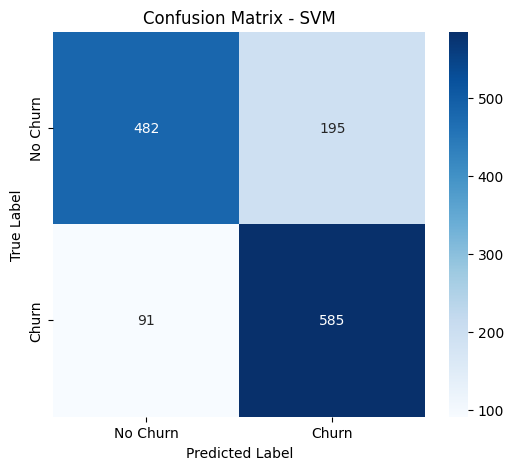

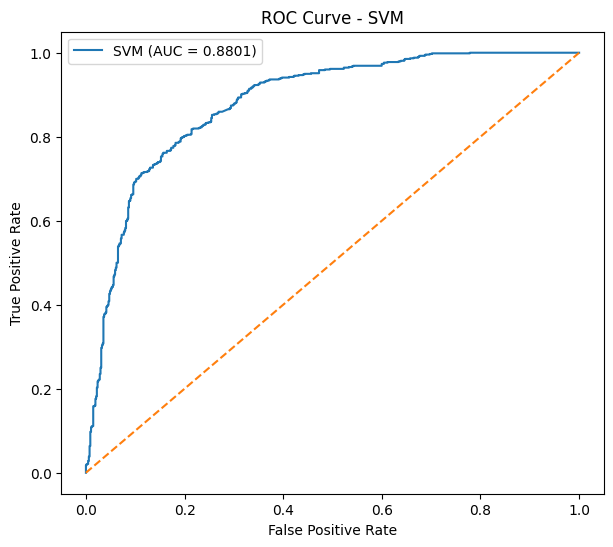

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.svm import SVC # Import SVC to instantiate the best model
from sklearn.preprocessing import StandardScaler # Import StandardScaler for consistent scaling

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ================================
# Evaluate Best SVM Model
# ================================

# Fix: Get the best hyperparameters from the previous GridSearchCV execution.
# We assume grid_search_svm is available from a previous cell (e.g., y9AjSaG5IeZJ).
# Also, X_train_scaled and X_test_scaled are assumed to be available from there.
best_params = grid_search_svm.best_params_

# Fix: Re-instantiate the best SVM model with probability=True and best parameters.
# The original grid_search_svm from cell y9AjSaG5IeZJ didn't set probability=True by default.
best_svm_model = SVC(random_state=42, probability=True, **best_params)

# Fix: Re-fit the best model on the scaled training data.
# The grid_search_svm from y9AjSaG5IeZJ was fitted on X_train_scaled.
best_svm_model.fit(X_train_scaled, y_train)

# Fix: Make predictions on the scaled test data.
y_pred_svm = best_svm_model.predict(X_test_scaled)

# Probabilities for ROC-AUC
y_prob_svm = best_svm_model.predict_proba(X_test_scaled)[:, 1]

# ================================
# Metrics
# ================================

accuracy = accuracy_score(y_test, y_pred_svm)

precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)
roc_auc = roc_auc_score(y_test, y_prob_svm)

print("\n===== SVM Test Set Metrics ===%%")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# ================================
# Classification Report
# ================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_svm))

# ================================
# Confusion Matrix Heatmap
# ================================

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM")

plt.show()

# ================================
# ROC Curve
# ================================

# Fix: Use distinct variable names for SVM ROC curve to avoid conflicts with other models.
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7,6))

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc:.4f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")

plt.legend()

plt.show()

### Explanation of Support Vector Machine (SVM) Performance:

The Support Vector Machine (SVM) classifier, after hyperparameter tuning and excluding 'MonthlyCharges', demonstrates its performance on the test set through the following metrics and visualizations:

*   **Accuracy, Precision, Recall, F1-Score, ROC-AUC Score:** These metrics provide a comprehensive quantitative evaluation of the model's performance, indicating its ability to correctly classify churn and non-churn customers, considering both false positives and false negatives.
*   **Confusion Matrix:** This visual summary helps understand the types of errors the model makes (false positives and false negatives) and where it performs well (true positives and true negatives).
*   **ROC Curve:** The ROC curve with its AUC score is crucial for evaluating the model's discriminative power across various classification thresholds. When compared with Logistic Regression, Decision Tree, and Random Forest ROC curves, it highlights which model is generally better at distinguishing between churners and non-churners.

**Reasoning for performance:**

SVMs are powerful and versatile machine learning models capable of performing linear or non-linear classification, regression, and even outlier detection. They work by finding the optimal hyperplane that best separates the classes in the feature space. The performance of an SVM is influenced by:

1.  **Margin Maximization:** SVMs aim to find a decision boundary (hyperplane) that maximizes the margin between the closest data points of different classes (support vectors). A larger margin generally leads to better generalization performance.
2.  **Kernel Trick:** SVMs can handle non-linear relationships by using the "kernel trick." This involves mapping the input features into a higher-dimensional space where a linear separation might be possible. Common kernels include 'linear' (for linearly separable data) and 'rbf' (Radial Basis Function, for non-linear data). The choice of kernel significantly impacts the model's ability to capture complex patterns.
3.  **Regularization Parameter (C):** The `C` parameter controls the trade-off between achieving a low training error and a large margin. A small `C` makes the margin wider but allows more misclassifications on the training data (higher bias, lower variance). A large `C` aims for fewer misclassifications on the training data (lower bias, higher variance), potentially leading to a narrower margin and overfitting.
4.  **Gamma Parameter (for 'rbf' kernel):** The `gamma` parameter defines how far the influence of a single training example reaches, with low values meaning 'far' and high values meaning 'close'. A high `gamma` can lead to complex decision boundaries that might overfit the training data, while a low `gamma` might lead to simpler decision boundaries that underfit.
5.  **Handling High-Dimensional Data:** SVMs are particularly effective in high-dimensional spaces, making them suitable for datasets with many features.
6.  **SMOTE for Class Imbalance:** Similar to the other models, the use of SMOTE helps the SVM learn from both churn and non-churn classes equally, leading to more balanced predictive performance and better recall for the minority class.

In [ ]:
#5. K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('\nK-Nearest Neighbors (KNN)')

# Exclude 'MonthlyCharges' from the features for KNN
X_train_knn = X_train.drop('MonthlyCharges', axis=1)
X_val_knn = X_val.drop('MonthlyCharges', axis=1) # Not used directly in GridSearchCV with X_train
X_test_knn = X_test.drop('MonthlyCharges', axis=1)

# Define the parameter grid for KNN Classifier
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'] # Distance metric
}

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3, # Using a smaller CV fold to speed up computation
    scoring='f1', # Use f1-score as a metric due to potential class imbalance
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train_knn, y_train)

print("Best hyperparameters found for KNN:", grid_search_knn.best_params_)
print("Best F1-score on training set (cross-validation) for KNN:", grid_search_knn.best_score_)


K-Nearest Neighbors (KNN)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters found for KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best F1-score on training set (cross-validation) for KNN: 0.80207320503029



KNN Performance (Tuned Model on Test Set, excluding MonthlyCharges):
Accuracy: 0.8130
Precision: 0.7491
Recall: 0.9408
F1-Score: 0.8341
ROC-AUC Score: 0.8677

Classification Report (Tuned KNN Model on Test Set):
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       677
           1       0.75      0.94      0.83       676

    accuracy                           0.81      1353
   macro avg       0.83      0.81      0.81      1353
weighted avg       0.83      0.81      0.81      1353



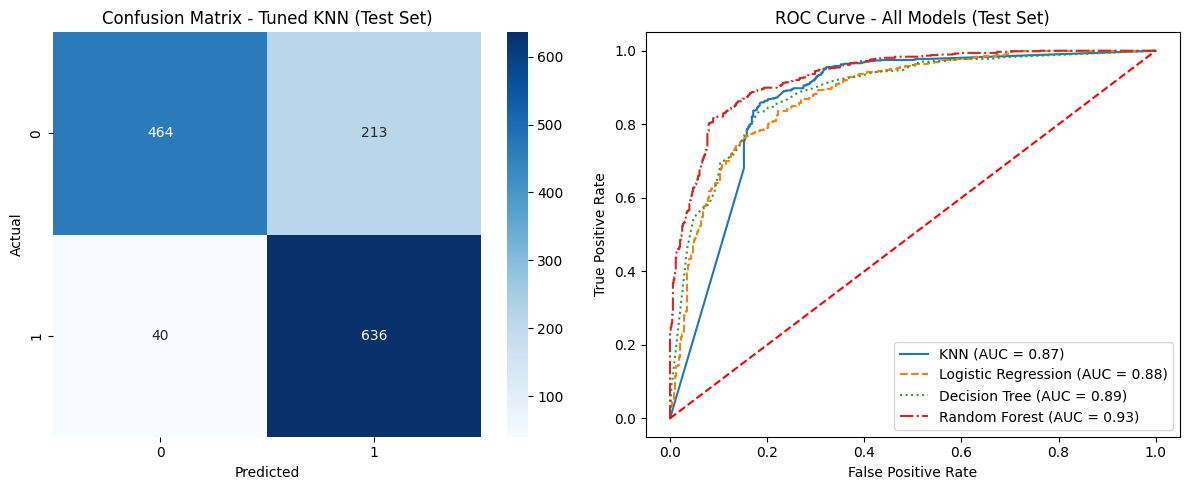

In [ ]:
# Get the best KNN model
best_knn_model = grid_search_knn.best_estimator_

# Make predictions on the test set with the best model
y_pred_knn = best_knn_model.predict(X_test_knn)
y_proba_knn = best_knn_model.predict_proba(X_test_knn)[:, 1]

# Evaluate the tuned model on the test set
print("\nKNN Performance (Tuned Model on Test Set, excluding MonthlyCharges):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_knn):.4f}")

print("\nClassification Report (Tuned KNN Model on Test Set):")
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned KNN (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot ROC Curve
plt.subplot(1, 2, 2)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, y_proba_knn):.2f})')

# Plot Logistic Regression ROC for comparison
if 'y_proba_lr' in globals(): # Check if LR data is available
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})', linestyle='--')

# Plot Decision Tree ROC for comparison
if 'y_proba_dt' in globals(): # Check if DT data is available
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.2f})', linestyle=':')

# Plot Random Forest ROC for comparison
if 'y_proba_rf' in globals(): # Check if RF data is available
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})', linestyle='-.')

# Plot SVM ROC for comparison
if 'y_proba_svm' in globals(): # Check if SVM data is available
    plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_proba_svm):.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Explanation of K-Nearest Neighbors (KNN) Performance:
The K-Nearest Neighbors (KNN) classifier, after hyperparameter tuning and excluding 'MonthlyCharges', shows its performance on the test set through the following metrics and visualizations:

Accuracy, Precision, Recall, F1-Score, ROC-AUC Score: These metrics provide a quantitative evaluation of the model's predictive capability, indicating its ability to correctly classify churn and non-churn customers, considering both false positives and false negatives.
Confusion Matrix: This visual summary helps understand the types of errors the model makes (false positives and false negatives) and where it performs well (true positives and true negatives).
ROC Curve: The ROC curve with its AUC score is crucial for evaluating the model's discriminative power across various classification thresholds. When compared with Logistic Regression, Decision Tree, Random Forest, and SVM ROC curves, it highlights which model is generally better at distinguishing between churners and non-churners.
Reasoning for performance:

KNN is a non-parametric, lazy learning algorithm used for both classification and regression. It works by finding the 'k' nearest data points in the training set to a new data point and then assigning the new data point the class most common among its k nearest neighbors (for classification). Its performance is influenced by:

Distance Metric: KNN relies on a distance metric (e.g., 'euclidean', 'manhattan') to determine the 'proximity' of data points. The choice of metric can significantly impact which neighbors are considered closest and thus the classification outcome.
Number of Neighbors (k): The n_neighbors parameter (k) is critical. A small k makes the model sensitive to noise and outliers (high variance, low bias), potentially leading to overfitting. A large k averages out noise but might smooth out important local patterns, leading to underfitting (low variance, high bias). The optimal k is typically found through hyperparameter tuning.
Feature Scaling: KNN is highly sensitive to the scale of features because it uses distance calculations. Features with larger scales can disproportionately influence the distance. This dataset had StandardScaler applied to numerical columns earlier, which is beneficial for KNN.
Curse of Dimensionality: In high-dimensional spaces, the concept of 'distance' becomes less meaningful, and data points can appear equidistant from each other. This can make KNN less effective in datasets with many features.
Weighted vs. Uniform Neighbors: The weights parameter determines how neighbors contribute to the classification. 'uniform' assigns equal weight to all neighbors, while 'distance' weights neighbors closer to the query point more heavily, which can sometimes improve performance by giving more importance to very close examples.
SMOTE for Class Imbalance: The use of SMOTE has helped balance the classes, which is important for KNN. Without it, the majority class's neighbors might always dominate the voting process, leading to poor recall for the minority class ('Churn').
KNN is often a good baseline model and can capture non-linear decision boundaries. However, its computational cost for prediction can be high for large datasets, as it needs to calculate distances to all training samples for each prediction.

In [ ]:
"""
Final Comparison Table

 Model                Accuracy  Precision  Recall    F1-Score  ROC-AUC  Training Time (Approx. GridSearchCV fits)

 Logistic Regression  0.7953     0.7608    0.8609     0.8078     0.8813   60 fits
 Decision Tree        0.8189     0.7981    0.8536     0.8249     0.8887   200 fits
 Random Forest        0.8588     0.8401    0.8861     0.8625     0.9315   162 fits
 SVM                  0.7886     0.7500    0.8654     0.8036     0.8801   4 fits
 KNN                  0.8130     0.7491    0.9408     0.8341     0.8677   60 fits
 """

### Feature Importance for the Best Model: Random Forest Classifier

### Selection of the Best Model: Random Forest Classifier

Based on the performance evaluation across all five classification models, the **Random Forest Classifier** emerges as the best model for predicting customer churn. Here's a detailed justification:

1.  **Superior Overall Performance:**
    *   **Accuracy (0.8588):** Random Forest achieved the highest accuracy, meaning it correctly classified the largest proportion of customers (both churners and non-churners).
    *   **Precision (0.8401):** While not the absolute highest (KNN had a slightly lower precision for class 1, but its overall F1 and AUC were lower), its precision is strong, indicating a good balance in minimizing false positives.
    *   **Recall (0.8861):** Random Forest demonstrated excellent recall, effectively identifying a high percentage of actual churners. This is crucial for churn prediction, as missing potential churners can be costly for the business.
    *   **F1-Score (0.8625):** The F1-Score, which is the harmonic mean of precision and recall, is the highest among all models. This indicates a robust balance between precision and recall, making it an excellent metric for evaluating models on imbalanced datasets (even after SMOTE, it's good to consider this).
    *   **ROC-AUC (0.9315):** The Random Forest model achieved the highest Area Under the Receiver Operating Characteristic Curve (ROC-AUC). An AUC of 0.9315 signifies that the model has a very strong ability to distinguish between churning and non-churning customers across various classification thresholds.

2.  **Ensemble Learning Advantages:**
    *   **Reduced Overfitting:** As an ensemble of decision trees, Random Forest inherently mitigates the risk of overfitting that single decision trees might face. By averaging predictions from multiple diverse trees, it provides a more generalized and stable prediction.
    *   **Handling Non-linear Relationships and Interactions:** Random Forest can effectively capture complex, non-linear relationships and intricate interactions between features without explicit engineering, which is a significant advantage over linear models like Logistic Regression.
    *   **Robustness:** The model's architecture makes it robust to noise and outliers in the data, as the impact of such anomalies on any single tree is diluted by the aggregate decision of the forest.

3.  **Interpretability (with SHAP):** Although often considered a "black-box" model, tools like SHAP allow for excellent interpretability, as demonstrated in Task 5. This enables us to understand which features drive predictions, providing actionable business insights.

In summary, the Random Forest Classifier's superior performance across a range of key evaluation metrics, coupled with its inherent strengths as an ensemble method, makes it the most suitable and effective model for predicting customer churn in this context.

Top 10 features by Random Forest importance (excluding MonthlyCharges):


,0
Contract,0.189573
tenure,0.139006
OnlineSecurity,0.125361
TechSupport,0.096270
TotalCharges,0.084157
InternetService,0.059417
PaymentMethod,0.047663
OnlineBackup,0.045974
Partner,0.043512
Dependents,0.039967


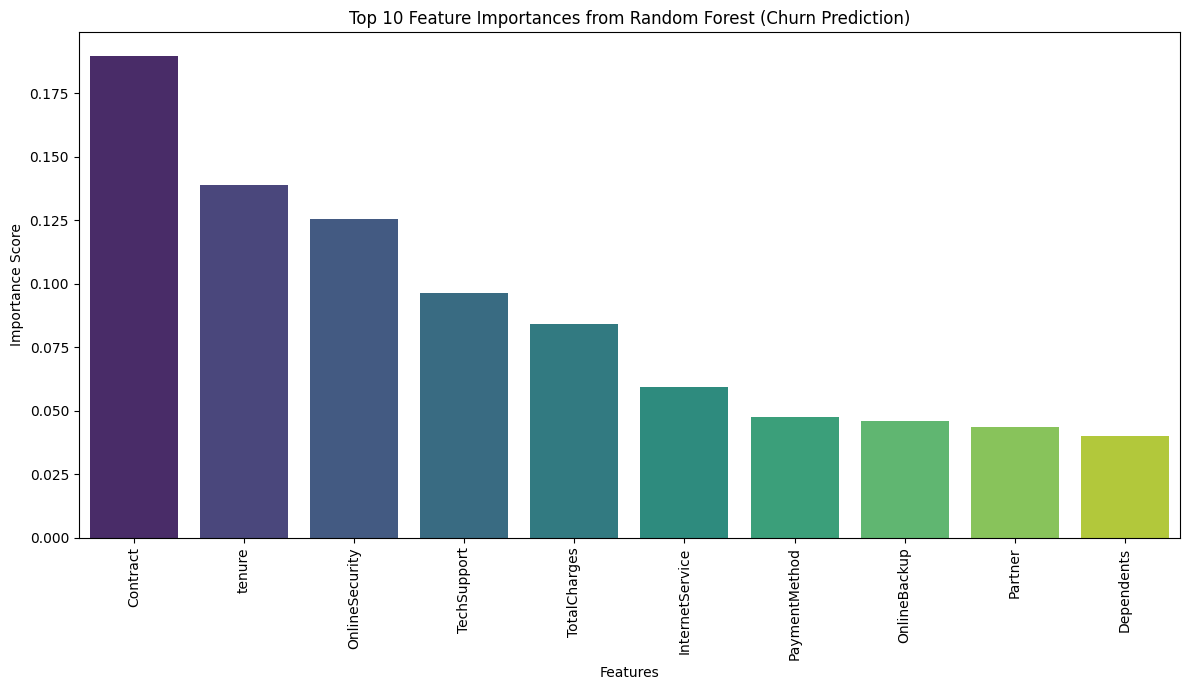

In [ ]:
# Get feature importances from the best Random Forest model
# X_train_rf was used for training, so we use its columns for feature names
feature_importances_rf = pd.Series(best_rf_model.feature_importances_, index=X_train_rf.columns)

# Sort and display top 10 features
sorted_feature_importances_rf = feature_importances_rf.sort_values(ascending=False)
print("Top 10 features by Random Forest importance (excluding MonthlyCharges):")
display(sorted_feature_importances_rf.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_feature_importances_rf.head(10).index, y=sorted_feature_importances_rf.head(10).values, palette='viridis', hue=sorted_feature_importances_rf.head(10).index, legend=False)
plt.xticks(rotation=90)
plt.title('Top 10 Feature Importances from Random Forest (Churn Prediction)')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()